<a href="https://colab.research.google.com/github/Vanitha-Jain/capstone/blob/Feature-selection/CDK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
data=pd.read_csv('/content/CDK.csv')
data

,Name,FP1,FP2,FP3,FP4,FP5,FP6,FP7,FP8,FP9,...,FP1016,FP1017,FP1018,FP1019,FP1020,FP1021,FP1022,FP1023,FP1024,bioactivity_class
0,CHEMBL167155,0,0,1,0,0,0,1,0,1,...,1,0,0,0,0,1,1,1,1,inactive
1,CHEMBL166740,0,0,1,0,0,0,1,1,0,...,0,0,0,0,0,1,1,1,0,inactive
2,CHEMBL165038,0,0,1,0,0,0,1,0,1,...,1,1,0,0,0,1,1,1,1,inactive
3,CHEMBL435857,0,0,1,0,0,0,1,0,1,...,1,1,0,0,0,1,1,1,1,inactive
4,CHEMBL352783,0,0,1,0,0,0,1,0,1,...,1,0,0,0,0,1,1,1,0,inactive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,CHEMBL5429863,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,inactive
1225,CHEMBL5436920,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,inactive
1226,CHEMBL5405698,0,0,0,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,inactive
1227,CHEMBL5416562,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,inactive


In [ ]:
data.dtypes

,0
Name,object
FP1,int64
FP2,int64
FP3,int64
FP4,int64
...,...
FP1021,int64
FP1022,int64
FP1023,int64
FP1024,int64


In [ ]:
data['bioactivity_class'].replace('active', 'P', inplace=True)
data['bioactivity_class'].replace('inactive', 'N', inplace=True)
data.rename(columns = {"bioactivity_class": "class"}, inplace = True)
data

<ipython-input-51-d75cbf56e791>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['bioactivity_class'].replace('active', 'P', inplace=True)
<ipython-input-51-d75cbf56e791>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

,Name,FP1,FP2,FP3,FP4,FP5,FP6,FP7,FP8,FP9,...,FP1016,FP1017,FP1018,FP1019,FP1020,FP1021,FP1022,FP1023,FP1024,class
0,CHEMBL167155,0,0,1,0,0,0,1,0,1,...,1,0,0,0,0,1,1,1,1,N
1,CHEMBL166740,0,0,1,0,0,0,1,1,0,...,0,0,0,0,0,1,1,1,0,N
2,CHEMBL165038,0,0,1,0,0,0,1,0,1,...,1,1,0,0,0,1,1,1,1,N
3,CHEMBL435857,0,0,1,0,0,0,1,0,1,...,1,1,0,0,0,1,1,1,1,N
4,CHEMBL352783,0,0,1,0,0,0,1,0,1,...,1,0,0,0,0,1,1,1,0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,CHEMBL5429863,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,N
1225,CHEMBL5436920,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,N
1226,CHEMBL5405698,0,0,0,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,N
1227,CHEMBL5416562,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,N


In [ ]:
data.isnull().sum().sum()

0

In [ ]:
data.dropna(inplace =True)
data.isnull().sum().sum()

0

In [ ]:
data1 = data.iloc[:,1:1025]
data1
data2 = data.iloc[:,-1]

In [ ]:
data1
data2

,class
0,N
1,N
2,N
3,N
4,N
...,...
1224,N
1225,N
1226,N
1227,N


In [ ]:
from sklearn.feature_selection import VarianceThreshold
threshold = VarianceThreshold(threshold=.1)
def variance_threshold_selector(data1, threshold=0.10):
    selector = VarianceThreshold(threshold)
    selector.fit(data1)
    return data[data1.columns[selector.get_support(indices=True)]]
data1_HV = variance_threshold_selector(data1)

In [ ]:
data1_HV = variance_threshold_selector(data1)
data1_HV

,FP1,FP2,FP3,FP4,FP5,FP6,FP7,FP9,FP10,FP11,...,FP1015,FP1016,FP1017,FP1018,FP1019,FP1020,FP1021,FP1022,FP1023,FP1024
0,0,0,1,0,0,0,1,1,0,1,...,0,1,0,0,0,0,1,1,1,1
1,0,0,1,0,0,0,1,0,0,1,...,0,0,0,0,0,0,1,1,1,0
2,0,0,1,0,0,0,1,1,0,1,...,0,1,1,0,0,0,1,1,1,1
3,0,0,1,0,0,0,1,1,0,1,...,0,1,1,0,0,0,1,1,1,1
4,0,0,1,0,0,0,1,1,0,1,...,0,1,0,0,0,0,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,0,0,0,0,0,0,0,0,0,0,...,1,1,0,0,0,0,1,0,0,0
1225,0,0,0,0,0,0,0,0,0,0,...,1,1,0,0,0,0,0,0,0,0
1226,0,0,0,0,0,0,0,0,0,0,...,1,1,0,0,0,1,0,0,0,0
1227,0,0,0,0,0,0,0,0,0,0,...,1,1,0,0,0,0,0,0,0,0


In [ ]:
data2_HV = pd.merge(data1_HV,data2,left_index=True,right_index=True)
data2_HV

,FP1,FP2,FP3,FP4,FP5,FP6,FP7,FP9,FP10,FP11,...,FP1016,FP1017,FP1018,FP1019,FP1020,FP1021,FP1022,FP1023,FP1024,class
0,0,0,1,0,0,0,1,1,0,1,...,1,0,0,0,0,1,1,1,1,N
1,0,0,1,0,0,0,1,0,0,1,...,0,0,0,0,0,1,1,1,0,N
2,0,0,1,0,0,0,1,1,0,1,...,1,1,0,0,0,1,1,1,1,N
3,0,0,1,0,0,0,1,1,0,1,...,1,1,0,0,0,1,1,1,1,N
4,0,0,1,0,0,0,1,1,0,1,...,1,0,0,0,0,1,1,1,0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,N
1225,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,N
1226,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,N
1227,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,N


In [ ]:
## remove features that display high correlation with many othe features
correlated_features_1 = set()
corr_matrix_class = data2_HV.corr(numeric_only=True)


for i in range(len(corr_matrix_class.columns)):
    for j in range(i):
        if abs(corr_matrix_class.iloc[i, j]) > 0.8:
            colname = corr_matrix_class.columns[i]
            correlated_features_1.add(colname)
correlated_features_1

{'FP212', 'FP493', 'FP889'}

In [ ]:
def remove_correlated_features(features, data):
    for x in features:
        data.drop(x, axis=1, inplace=True)
    return data

In [ ]:
data3= remove_correlated_features(correlated_features_1, data2_HV)
data3

,FP1,FP2,FP3,FP4,FP5,FP6,FP7,FP9,FP10,FP11,...,FP1016,FP1017,FP1018,FP1019,FP1020,FP1021,FP1022,FP1023,FP1024,class
0,0,0,1,0,0,0,1,1,0,1,...,1,0,0,0,0,1,1,1,1,N
1,0,0,1,0,0,0,1,0,0,1,...,0,0,0,0,0,1,1,1,0,N
2,0,0,1,0,0,0,1,1,0,1,...,1,1,0,0,0,1,1,1,1,N
3,0,0,1,0,0,0,1,1,0,1,...,1,1,0,0,0,1,1,1,1,N
4,0,0,1,0,0,0,1,1,0,1,...,1,0,0,0,0,1,1,1,0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,N
1225,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,N
1226,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,N
1227,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,N


In [ ]:
data3.to_csv('CDK1.csv')

In [ ]:
X = data3.iloc[:,1:995]  #independent columns
X
y = data3.iloc[:,-1]
y   #target column i.e price range

,class
0,N
1,N
2,N
3,N
4,N
...,...
1224,N
1225,N
1226,N
1227,N


In [ ]:
X


,FP2,FP3,FP4,FP5,FP6,FP7,FP9,FP10,FP11,FP12,...,FP1015,FP1016,FP1017,FP1018,FP1019,FP1020,FP1021,FP1022,FP1023,FP1024
0,0,1,0,0,0,1,1,0,1,0,...,0,1,0,0,0,0,1,1,1,1
1,0,1,0,0,0,1,0,0,1,0,...,0,0,0,0,0,0,1,1,1,0
2,0,1,0,0,0,1,1,0,1,0,...,0,1,1,0,0,0,1,1,1,1
3,0,1,0,0,0,1,1,0,1,0,...,0,1,1,0,0,0,1,1,1,1
4,0,1,0,0,0,1,1,0,1,0,...,0,1,0,0,0,0,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,0,0,0,0,0,0,0,0,0,0,...,1,1,0,0,0,0,1,0,0,0
1225,0,0,0,0,0,0,0,0,0,0,...,1,1,0,0,0,0,0,0,0,0
1226,0,0,0,0,0,0,0,0,0,0,...,1,1,0,0,0,1,0,0,0,0
1227,0,0,0,0,0,0,0,0,0,0,...,1,1,0,0,0,0,0,0,0,0


In [ ]:
from sklearn.preprocessing import StandardScaler
# y = data['class']
# X_features =data.drop(columns='class')
scaler = StandardScaler()
X_transform = scaler.fit_transform(X)
X_transform_pd = pd.DataFrame(X_transform, columns = X.columns)
X_transform_pd

# #Standardize/normalize the data
# from sklearn.preprocessing import MinMaxScaler
# sc = MinMaxScaler()
# X_transform = sc.fit_transform(X)
# X_transform

,FP2,FP3,FP4,FP5,FP6,FP7,FP9,FP10,FP11,FP12,...,FP1015,FP1016,FP1017,FP1018,FP1019,FP1020,FP1021,FP1022,FP1023,FP1024
0,-0.69077,2.248152,-0.443497,-0.597086,-0.634798,1.257749,1.828321,-0.408829,1.803495,-0.78556,...,-0.964031,0.677953,-0.649964,-0.590819,-0.51673,-0.423630,1.916508,1.836754,1.921156,2.613049
1,-0.69077,2.248152,-0.443497,-0.597086,-0.634798,1.257749,-0.546950,-0.408829,1.803495,-0.78556,...,-0.964031,-1.475029,-0.649964,-0.590819,-0.51673,-0.423630,1.916508,1.836754,1.921156,-0.382695
2,-0.69077,2.248152,-0.443497,-0.597086,-0.634798,1.257749,1.828321,-0.408829,1.803495,-0.78556,...,-0.964031,0.677953,1.538546,-0.590819,-0.51673,-0.423630,1.916508,1.836754,1.921156,2.613049
3,-0.69077,2.248152,-0.443497,-0.597086,-0.634798,1.257749,1.828321,-0.408829,1.803495,-0.78556,...,-0.964031,0.677953,1.538546,-0.590819,-0.51673,-0.423630,1.916508,1.836754,1.921156,2.613049
4,-0.69077,2.248152,-0.443497,-0.597086,-0.634798,1.257749,1.828321,-0.408829,1.803495,-0.78556,...,-0.964031,0.677953,-0.649964,-0.590819,-0.51673,-0.423630,1.916508,1.836754,1.921156,-0.382695
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,-0.69077,-0.444810,-0.443497,-0.597086,-0.634798,-0.795071,-0.546950,-0.408829,-0.554479,-0.78556,...,1.037311,0.677953,-0.649964,-0.590819,-0.51673,-0.423630,1.916508,-0.544439,-0.520520,-0.382695
1225,-0.69077,-0.444810,-0.443497,-0.597086,-0.634798,-0.795071,-0.546950,-0.408829,-0.554479,-0.78556,...,1.037311,0.677953,-0.649964,-0.590819,-0.51673,-0.423630,-0.521782,-0.544439,-0.520520,-0.382695
1226,-0.69077,-0.444810,-0.443497,-0.597086,-0.634798,-0.795071,-0.546950,-0.408829,-0.554479,-0.78556,...,1.037311,0.677953,-0.649964,-0.590819,-0.51673,2.360549,-0.521782,-0.544439,-0.520520,-0.382695
1227,-0.69077,-0.444810,-0.443497,-0.597086,-0.634798,-0.795071,-0.546950,-0.408829,-0.554479,-0.78556,...,1.037311,0.677953,-0.649964,-0.590819,-0.51673,-0.423630,-0.521782,-0.544439,-0.520520,-0.382695


In [ ]:
## Split data into train and test sets.
from sklearn.model_selection import train_test_split
seed_num = 10
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.3, random_state=seed_num)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)


(860, 994)
(860,)
(369, 994)
(369,)


In [ ]:
X_train

,FP2,FP3,FP4,FP5,FP6,FP7,FP9,FP10,FP11,FP12,...,FP1015,FP1016,FP1017,FP1018,FP1019,FP1020,FP1021,FP1022,FP1023,FP1024
387,1,0,0,0,0,1,0,0,0,1,...,1,1,1,0,0,1,0,1,0,0
250,1,0,0,0,0,0,1,0,0,0,...,1,1,0,1,0,0,0,0,0,1
378,1,1,0,1,1,1,1,0,0,1,...,1,1,1,0,1,1,0,0,0,0
73,0,0,1,0,1,0,0,0,0,0,...,1,1,0,1,0,1,1,0,0,0
1185,0,0,0,0,0,0,0,0,0,0,...,0,1,1,0,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
733,0,0,0,0,1,0,1,0,0,0,...,1,1,0,0,0,0,0,1,0,0
1180,0,0,0,0,0,0,0,0,0,0,...,1,0,1,0,0,0,0,0,0,0
1147,0,0,0,0,0,0,0,0,1,1,...,0,1,0,0,0,0,0,1,0,0
527,0,0,0,0,0,0,0,1,0,1,...,0,1,0,0,0,1,1,0,1,0


In [ ]:
y_train

,class
387,N
250,N
378,N
73,N
1185,P
...,...
733,N
1180,P
1147,N
527,P


In [ ]:
Training_set  = pd.concat([X_train,y_train],axis=1)
Training_set

,FP2,FP3,FP4,FP5,FP6,FP7,FP9,FP10,FP11,FP12,...,FP1016,FP1017,FP1018,FP1019,FP1020,FP1021,FP1022,FP1023,FP1024,class
387,1,0,0,0,0,1,0,0,0,1,...,1,1,0,0,1,0,1,0,0,N
250,1,0,0,0,0,0,1,0,0,0,...,1,0,1,0,0,0,0,0,1,N
378,1,1,0,1,1,1,1,0,0,1,...,1,1,0,1,1,0,0,0,0,N
73,0,0,1,0,1,0,0,0,0,0,...,1,0,1,0,1,1,0,0,0,N
1185,0,0,0,0,0,0,0,0,0,0,...,1,1,0,0,0,0,1,1,0,P
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
733,0,0,0,0,1,0,1,0,0,0,...,1,0,0,0,0,0,1,0,0,N
1180,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,P
1147,0,0,0,0,0,0,0,0,1,1,...,1,0,0,0,0,0,1,0,0,N
527,0,0,0,0,0,0,0,1,0,1,...,1,0,0,0,1,1,0,1,0,P


In [ ]:
Training_set.to_csv('CDK_Training_set.csv')

In [ ]:
Testing_set  = pd.concat([X_test,y_test],axis=1)
Testing_set

,FP2,FP3,FP4,FP5,FP6,FP7,FP9,FP10,FP11,FP12,...,FP1016,FP1017,FP1018,FP1019,FP1020,FP1021,FP1022,FP1023,FP1024,class
693,0,0,0,0,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,0,N
834,1,1,0,0,0,1,0,0,1,0,...,1,0,1,1,0,0,0,0,0,N
1016,1,0,1,0,0,1,0,0,1,0,...,1,0,0,0,0,0,0,0,0,P
1113,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,P
31,0,0,0,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,P
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1102,1,0,0,1,0,1,1,1,0,0,...,0,0,1,0,0,0,0,0,0,P
909,0,0,0,0,1,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,P
270,1,0,0,1,1,1,1,0,0,0,...,1,0,1,0,0,0,0,0,1,N
349,0,0,0,1,0,0,1,0,0,1,...,1,1,0,1,0,0,1,0,0,P


In [ ]:
Testing_set.to_csv('CDK_Testing_set.csv')

In [ ]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
kBest = SelectKBest(mutual_info_classif, k = 15)
X_kBestFeatures = kBest.fit_transform(X_train, y_train)
X_kBestFeatures.shape

(860, 15)

In [ ]:
kBest.get_support(True)

array([ 61, 128, 149, 155, 284, 423, 529, 630, 704, 737, 744, 813, 856,
       860, 919])

In [ ]:
X_kBestFeatures = Training_set.iloc[:, kBest.get_support(True)]
X_kBestFeatures.columns

Index(['FP67', 'FP135', 'FP157', 'FP164', 'FP296', 'FP437', 'FP544', 'FP648',
       'FP726', 'FP763', 'FP770', 'FP840', 'FP884', 'FP888', 'FP949'],
      dtype='object')

In [ ]:
f = kBest.get_support(1)
X_new = X_train[X_train.columns[f]]
X_new
data_scores = pd.DataFrame(kBest.scores_)
data_columns = pd.DataFrame(X.columns)

In [ ]:
#Concat two dataframes for better visualization
featureScores = pd.concat([data_columns, data_scores], axis = 1)

#naming the dataframe columns
featureScores.columns = ['Features', 'Scores']
featureScores


,Features,Scores
0,FP2,0.000000
1,FP3,0.000000
2,FP4,0.002826
3,FP5,0.000372
4,FP6,0.000000
...,...,...
989,FP1020,0.000000
990,FP1021,0.000000
991,FP1022,0.000000
992,FP1023,0.000000


In [ ]:
#Print top 25 best features
print(featureScores.nlargest(15, 'Scores'))

    Features    Scores
860    FP888  0.081351
149    FP157  0.078415
630    FP648  0.069605
529    FP544  0.068634
856    FP884  0.068090
128    FP135  0.065556
284    FP296  0.060153
155    FP164  0.058887
704    FP726  0.058695
423    FP437  0.058084
813    FP840  0.057447
61      FP67  0.056097
744    FP770  0.055357
737    FP763  0.054718
919    FP949  0.054549


In [ ]:
Graph = (featureScores.nlargest(15, 'Scores'))
Graph

,Features,Scores
860,FP888,0.081351
149,FP157,0.078415
630,FP648,0.069605
529,FP544,0.068634
856,FP884,0.068090
128,FP135,0.065556
284,FP296,0.060153
155,FP164,0.058887
704,FP726,0.058695
423,FP437,0.058084


In [ ]:
Graph.to_csv('CDK_Features.csv')

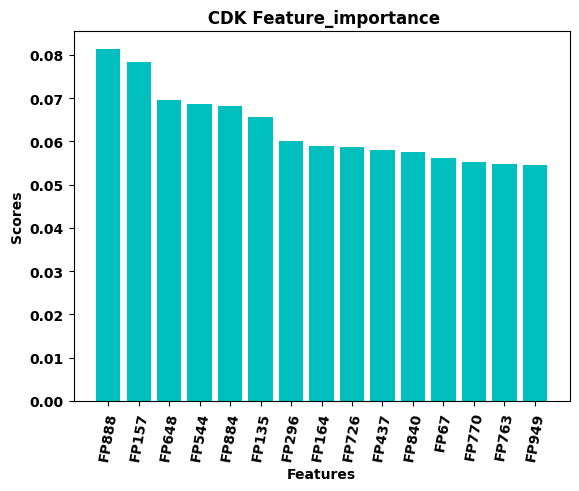

<Figure size 1000x1000 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
data = pd.read_csv('CDK_Features.csv')
df = pd.DataFrame(data)
X = list(df.iloc[:, 1])
Y = list(df.iloc[:, 2])
plt.bar(X, Y, color='c')
plt.title(" CDK Feature_importance", fontweight="bold")
plt.xlabel("Features", fontweight = 'bold')
plt.ylabel("Scores", fontweight = 'bold')
plt.xticks(rotation = 80, fontweight="bold")
plt.yticks(fontweight="bold")
fig = plt.figure(figsize=(10, 10))
plt.savefig("Features.jpg", bbox_inches = 'tight')

In [ ]:
Trainset = pd.concat([X_new,y_train],axis=1)
Trainset

,FP67,FP135,FP157,FP164,FP296,FP437,FP544,FP648,FP726,FP763,FP770,FP840,FP884,FP888,FP949,class
387,0,1,1,1,0,0,1,1,0,0,1,0,0,0,1,N
250,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,N
378,0,1,1,1,0,0,1,0,1,0,0,0,0,0,1,N
73,1,1,0,0,0,1,1,0,0,0,1,1,1,0,1,N
1185,0,0,1,1,0,1,1,1,0,0,1,0,1,1,1,P
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
733,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,N
1180,1,0,1,0,1,1,1,0,0,0,1,1,1,1,1,P
1147,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,N
527,1,0,0,0,0,0,1,0,0,0,0,0,1,0,1,P


In [ ]:
f = kBest.get_support(1)
Test_new = X_test[X_test.columns[f]]
Test_new

,FP67,FP135,FP157,FP164,FP296,FP437,FP544,FP648,FP726,FP763,FP770,FP840,FP884,FP888,FP949
693,0,1,1,0,0,0,0,0,0,0,0,1,1,0,0
834,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0
1016,1,0,0,1,0,1,1,1,1,1,1,0,1,1,1
1113,0,0,0,0,0,1,1,0,0,0,0,0,1,1,0
31,0,1,1,1,0,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1102,1,0,1,1,0,0,1,1,1,1,1,0,1,0,1
909,1,1,0,1,1,1,1,0,1,1,1,1,0,1,1
270,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0
349,1,0,1,0,0,0,1,1,0,1,0,1,1,1,1


In [ ]:
Testset = pd.concat([Test_new,y_test],axis=1)
Testset

,FP67,FP135,FP157,FP164,FP296,FP437,FP544,FP648,FP726,FP763,FP770,FP840,FP884,FP888,FP949,class
693,0,1,1,0,0,0,0,0,0,0,0,1,1,0,0,N
834,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,N
1016,1,0,0,1,0,1,1,1,1,1,1,0,1,1,1,P
1113,0,0,0,0,0,1,1,0,0,0,0,0,1,1,0,P
31,0,1,1,1,0,0,0,0,0,0,1,0,0,0,0,P
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1102,1,0,1,1,0,0,1,1,1,1,1,0,1,0,1,P
909,1,1,0,1,1,1,1,0,1,1,1,1,0,1,1,P
270,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0,N
349,1,0,1,0,0,0,1,1,0,1,0,1,1,1,1,P


In [ ]:
Trainset.to_csv('Trainset_CDK_after_feature.csv')
Testset.to_csv('Testset_CDK_after_feature.csv')

In [ ]:
Trainset['class'].replace('N', 0, inplace=True)
Trainset['class'].replace('P', 1, inplace=True)
Trainset.rename(columns = {"class": "class"}, inplace = True)
Trainset

<ipython-input-93-e976ed617192>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Trainset['class'].replace('N', 0, inplace=True)
<ipython-input-93-e976ed617192>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using

,FP67,FP135,FP157,FP164,FP296,FP437,FP544,FP648,FP726,FP763,FP770,FP840,FP884,FP888,FP949,class
387,0,1,1,1,0,0,1,1,0,0,1,0,0,0,1,0
250,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0
378,0,1,1,1,0,0,1,0,1,0,0,0,0,0,1,0
73,1,1,0,0,0,1,1,0,0,0,1,1,1,0,1,0
1185,0,0,1,1,0,1,1,1,0,0,1,0,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
733,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
1180,1,0,1,0,1,1,1,0,0,0,1,1,1,1,1,1
1147,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0
527,1,0,0,0,0,0,1,0,0,0,0,0,1,0,1,1


In [ ]:
Testset['class'].replace('N', 0, inplace=True)
Testset['class'].replace('P', 1, inplace=True)
Testset.rename(columns = {"class": "class"}, inplace = True)
Testset.head()

<ipython-input-94-c538cf0d9b31>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Testset['class'].replace('N', 0, inplace=True)
<ipython-input-94-c538cf0d9b31>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

,FP67,FP135,FP157,FP164,FP296,FP437,FP544,FP648,FP726,FP763,FP770,FP840,FP884,FP888,FP949,class
693,0,1,1,0,0,0,0,0,0,0,0,1,1,0,0,0
834,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0
1016,1,0,0,1,0,1,1,1,1,1,1,0,1,1,1,1
1113,0,0,0,0,0,1,1,0,0,0,0,0,1,1,0,1
31,0,1,1,1,0,0,0,0,0,0,1,0,0,0,0,1


In [ ]:
Trainset.to_csv('Trainset1_CDK_after_feature.csv')
Testset.to_csv('Testset1_CDK_after_feature.csv')